# CEE6501 — Coding Assignment, Week 5

**Assigned:** 02/13/2026 (Week 5)  
**Due:** 02/23/2026

**Canvas Submission Link:**  <https://gatech.instructure.com/courses/517856/assignments/2320760>

---

## Logistics

### 💻 Assignment Format

This is a **coding assignment**.

- Complete the assignment by **executing and completing all tasks in the notebook cells below**
- The notebook should be run and completed in **Google Colab**
- Your submission **must be a link to a functioning Google Colab notebook**

You may use any local tools (VS Code, JupyterLab, etc.) while working, but the **final submitted work must run correctly in Colab**.


### 📤 Submission Instructions

- Submit **one link** to your Google Colab notebook on Canvas
- Ensure that:
  - All cells run **top-to-bottom without errors**
  - All required outputs are visible
  - The notebook reflects your final answers

### ✅ Checklist Before Submitting

- [ ] All notebook cells completed
- [ ] Code runs without errors from a fresh runtime
- [ ] Outputs and plots are clearly visible
- [ ] Colab link opens and runs correctly
- [ ] Correct notebook submitted on Canvas

### 🤝 Collaboration / AI tools
You may discuss concepts with classmates and you may use AI tools to help you learn,
but **your submitted code must be written by you and you must understand it**.
If you used outside help, add a short note in the final reflection cell.

---

## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [210]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Not running in Google Colab — setup skipped.
Python version: 3.12.12


In [211]:
# --- Version check ---
import numpy
import scipy
import matplotlib
import pandas
import plotly

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("plotly:", plotly.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


---
---

## Imports

Run this cell once before starting the assignment.

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.set_printoptions(precision=3, suppress=True)


---

## GIVEN CODE (Do not modify):

## Parsing & Helper Functions

In [213]:
def restrained_dofs_1based(nodes_restrained, node_dofs_1based):
    """Return sorted list of restrained DOFs (1-based) from node restraints."""
    dof_restrained = []

    for node, restraints in nodes_restrained.items():
        ux_dof, uy_dof = node_dofs_1based(node)
        if "ux" in restraints:
            dof_restrained.append(ux_dof)
        if "uy" in restraints:
            dof_restrained.append(uy_dof)

    return sorted(dof_restrained)

In [214]:
def loaded_dofs_1based(nodes_loaded, node_dofs_1based):
    """Return DOF→load mapping (1-based) from node loads."""
    dof_loaded = {}

    for node, (Fx, Fy) in nodes_loaded.items():
        ux_dof, uy_dof = node_dofs_1based(node)
        if Fx != 0.0:
            dof_loaded[ux_dof] = dof_loaded.get(ux_dof, 0.0) + Fx
        if Fy != 0.0:
            dof_loaded[uy_dof] = dof_loaded.get(uy_dof, 0.0) + Fy

    return dof_loaded


In [215]:
def node_dofs_1based(node_id):
    """Return engineering DOF numbers (1-based): [ux_dof, uy_dof]."""
    return [2 * node_id - 1, 2 * node_id]

## Element Level

In [216]:
def element_csL(xy_i, xy_j):
    xy_i = np.asarray(xy_i, dtype=float)
    xy_j = np.asarray(xy_j, dtype=float)

    dx = xy_j[0] - xy_i[0]
    dy = xy_j[1] - xy_i[1]
    L = float(np.hypot(dx, dy))

    c = dx / L
    s = dy / L
    return float(c), float(s), float(L)

In [217]:
def build_elements_csl(elements, nodes):
    """Return dict mapping element_id -> (c, s, L)."""
    elements_csl = {}

    for e_id, (i, j, E_e, A_e) in elements.items():
        c, s, L = element_csL(nodes[i], nodes[j])
        elements_csl[e_id] = (c, s, L)

    return elements_csl

## Global Stiffness and Force

In [218]:
def initialize_global_stiffness(nodes):
    """Return zero-initialized global stiffness matrix."""
    ndof_total = 2 * len(nodes)
    return np.zeros((ndof_total, ndof_total), dtype=float)

In [219]:
def truss_element_kg(E, A, c, s, L):
    """Return 4x4 global stiffness matrix for a 2D truss element."""
    factor = (E * A) / L

    c2 = c * c
    s2 = s * s
    cs = c * s

    kg = factor * np.array(
        [
            [ c2,  cs, -c2, -cs],
            [ cs,  s2, -cs, -s2],
            [-c2, -cs,  c2,  cs],
            [-cs, -s2,  cs,  s2],
        ],
        dtype=float,
    )
    return kg

In [220]:
def element_dof_map_1based(i_node, j_node):
    """Return the 4 global DOF indices (1-based) for element (i, j).

    Order matches the 4x4 element stiffness matrix:
    [u_ix, u_iy, u_jx, u_jy]
    """
    # Engineering DOF numbers (1-based)
    dofs_i_1 = [2 * i_node - 1, 2 * i_node]
    dofs_j_1 = [2 * j_node - 1, 2 * j_node]
    dofs_1based = dofs_i_1 + dofs_j_1
    return dofs_1based

In [221]:
def assemble_global_stiffness(elements, nodes, elements_csl, print_toggle):
    """Assemble and return the global stiffness matrix K (dense) for a 2D truss."""

    K = initialize_global_stiffness(nodes)

    for e_id, (i, j, E_e, A_e) in elements.items():
        c, s, L = elements_csl[e_id]
        ke = truss_element_kg(E_e, A_e, c, s, L)
        
        dof_map = element_dof_map_1based(i, j)

        # Scatter-add ke into K. Must be 0-based indexing, hence -1
        for a in range(4):
            A = dof_map[a] - 1
            for b in range(4):
                B = dof_map[b] - 1
                K[A, B] += ke[a, b]

        # Optional: show progress while learning/debugging
        if print_toggle:
            print_matrix_scaled(ke)
            print(f"Assembled element {e_id}: nodes ({i},{j}) -> DOFs {dof_map}")
            print_matrix_scaled(K)
            print("-" * 70)

    return K

In [222]:
def assemble_global_force_vector(nodes, dof_loaded_1based):
    """Return global force vector assembled from 1-based DOF loads."""
    ndof_total = 2 * len(nodes)
    f_global = np.zeros(ndof_total, dtype=float)

    for dof_1based, value in dof_loaded_1based.items():
        f_global[dof_1based - 1] = value  # convert to 0-based index

    return f_global

## Partition

In [223]:
def partition_system(K, f, dof_restrained_1based):
    ndof = K.shape[0]

    # Convert restrained DOFs to 0-based
    restrained_dofs = sorted(d - 1 for d in dof_restrained_1based)

    # Free DOFs
    free_dofs = [i for i in range(ndof) if i not in restrained_dofs]

    # Partition stiffness matrix
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    K_fr = K[np.ix_(free_dofs, restrained_dofs)]
    K_rf = K[np.ix_(restrained_dofs, free_dofs)]
    K_rr = K[np.ix_(restrained_dofs, restrained_dofs)]

    # Partition force vector
    f_f = f[free_dofs]
    f_r = f[restrained_dofs]

    return K_ff, K_fr, K_rf, K_rr, f_f, f_r, free_dofs, restrained_dofs


## Solve Displacements

In [224]:
def solve_free_displacements(K_ff, K_fr, f_f, u_r=None):
    if u_r is None:
        u_r = np.zeros(K_fr.shape[1])

    rhs = f_f - K_fr @ u_r
    u_f = np.linalg.solve(K_ff, rhs)

    return u_f


## Solve Support Forces

In [225]:
def solve_support_forces(K_rf, K_rr, u_f, u_r=None):
    if u_r is None:
        u_r = np.zeros(K_rr.shape[0])

    F_r = K_rf @ u_f + K_rr @ u_r
    return F_r


## Backward Pass

In [226]:
def assemble_global_displacements(u_f, free_dofs, restrained_dofs, u_r=None):
    """
    Assemble the full global displacement vector u from partitioned results.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    u_global = np.zeros(ndof_total)

    if u_r is None:
        u_r = np.zeros(len(restrained_dofs))

    u_global[free_dofs] = u_f
    u_global[restrained_dofs] = u_r

    return u_global


In [227]:
def assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs):
    """
    Assemble the full global force vector f from applied loads and reactions.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    f_global = np.zeros(ndof_total)

    f_global[free_dofs] = f_f
    f_global[restrained_dofs] = F_r

    return f_global


In [228]:
def extract_element_displacements(u_global, i_node, j_node):
    """
    Extract the 4x1 element global displacement vector u_e.
    Order: [u_ix, u_iy, u_jx, u_jy]
    """
    dofs_1based = [2 * i_node - 1, 2 * i_node,
                   2 * j_node - 1, 2 * j_node]
    idx = [d - 1 for d in dofs_1based]  # convert to 0-based
    return u_global[idx]

In [229]:
def truss_transformation_matrix(c, s):
    return np.array(
        [
            [ c,  s,  0,  0],
            [-s,  c,  0,  0],
            [ 0,  0,  c,  s],
            [ 0,  0, -s,  c],
        ],
        dtype=float,
    )

def compute_local_displacements(c, s, u_e):
    T = truss_transformation_matrix(c, s)
    return T @ u_e



In [230]:
def truss_local_stiffness(E, A, L):
    return (E * A / L) * np.array(
        [
            [ 1, 0, -1, 0],
            [ 0, 0,  0, 0],
            [-1, 0,  1, 0],
            [ 0, 0,  0, 0],
        ],
        dtype=float,
    )

In [231]:
def compute_local_end_forces(E, A, L, u_local):
    k_local = truss_local_stiffness(E, A, L)
    return k_local @ u_local

In [232]:
def compute_axial_force_and_stress(E, A, L, u_local):
    # axial displacements are the local DOFs along the member axis
    u_i_axial = u_local[0]
    u_j_axial = u_local[2]

    N = (E * A / L) * (u_j_axial - u_i_axial)
    sigma = N / A
    return N, sigma

In [233]:
def local_to_global_forces(c, s, f_local):
    T = truss_transformation_matrix(c, s)
    return T.T @ f_local

## Post-Processing & Output

In [234]:
def plot_truss_deformation(nodes, elements, u_global, scale=1.0):
    """
    Plot original (black) and deformed (red) truss geometry.
    """
    plt.figure()

    for e_id, (i, j, *_ ) in elements.items():
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        ui = u_global[2*(i-1):2*(i-1)+2]
        uj = u_global[2*(j-1):2*(j-1)+2]

        # original
        plt.plot([xi, xj], [yi, yj], "k-", lw=2)

        # deformed
        plt.plot(
            [xi + scale*ui[0], xj + scale*uj[0]],
            [yi + scale*ui[1], yj + scale*uj[1]],
            "r-", lw=2
        )

    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Original (black) and deformed (red), scale={scale}")
    plt.show()


In [235]:
def recover_element_results(elements, elements_csl, u_global):
    results = {}

    for e_id, (i, j, E_e, A_e) in elements.items():
        c, s, L = elements_csl[e_id]

        u_e = extract_element_displacements(u_global, i, j)
        u_local = compute_local_displacements(c, s, u_e)
        f_local = compute_local_end_forces(E_e, A_e, L, u_local)
        N, sigma = compute_axial_force_and_stress(E_e, A_e, L, u_local)

        results[e_id] = {
            "u_e": u_e,
            "u_local": u_local,
            "f_local": f_local,
            "N": N,          # kN
            "sigma": sigma,  # GPa
        }

    return results

In [236]:
def build_element_results_dataframe(elements, elements_csl, results):
    """Return pandas DataFrame of element-level results."""
    rows = []

    for e_id in sorted(elements.keys()):
        i, j, _, _ = elements[e_id]
        _, _, L = elements_csl[e_id]
        r = results[e_id]

        row = {
            "ele": e_id,
            "i": i,
            "j": j,
            "L (mm)": round(L, 1),
            "N (kN)": round(r["N"], 1),
            "sigma (MPa)": round(r["sigma"] * 1000, 1),
        }

        # global displacements u_e
        row.update({f"u_{k+1} (mm)": round(r["u_e"][k], 1) for k in range(4)})
        # local displacements u'
        row.update({f"u_{k+1}' (mm)": round(r["u_local"][k], 1) for k in range(4)})
        # local end forces f'
        row.update({f"f_{k+1}' (kN)": round(r["f_local"][k], 1) for k in range(4)})

        rows.append(row)

    return pd.DataFrame(rows)


In [237]:
def display_compact(df):
    return (
        df.style
        .format({
            col: "{:.1f}"
            for col in df.columns
            if any(key in col for key in ["(mm)", "(kN)", "(MPa)", "L"])
        })
        .set_properties(**{
            "font-size": "9pt",
            "padding": "2px",
            "white-space": "nowrap",
        })
        .set_table_styles([
            {"selector": "th", "props": [("font-size", "9pt")]},
        ])
    )


In [238]:
def print_matrix_scaled(K, scale=1, decimals=2, col_width=7):
    """
    Print K/scale row-by-row, compact, with DOF labels.
    """
    fmt = f"{{:{col_width}.{decimals}f}}"
    print(f"K = {scale:.0e} ×")
    for i, row in enumerate(K, start=1):
        row_scaled = row / scale
        row_str = " ".join(fmt.format(val) for val in row_scaled)
        print(f"{i:2d} | {row_str}")

In [239]:
def build_global_load_vector(n_dof, dof_loaded_1based):
    """dof_loaded_1based: {dof(1-based): value}  ->  F (0-based numpy vector)"""
    F = np.zeros(n_dof, dtype=float)
    for dof1, val in dof_loaded_1based.items():
        F[dof1 - 1] += val
    return F

In [240]:
def build_reaction_df(nodes_restrained, node_dofs_1based,
                      K_global, u_global, dof_loaded_1based,
                      decimals=1):
    """
    Return a DataFrame with support reactions at restrained nodes.
    Units: same as your loads (e.g., kN).
    """
    n_dof = K_global.shape[0]
    F = build_global_load_vector(n_dof, dof_loaded_1based)

    R = K_global @ u_global - F

    rows = []
    for node in sorted(nodes_restrained.keys()):
        ux, uy = node_dofs_1based(node)

        Rx = R[ux - 1]
        Ry = R[uy - 1]

        rows.append({
            "node": node,
            "Rx (kN)": round(Rx, decimals),
            "Ry (kN)": round(Ry, decimals)
        })

    return pd.DataFrame(rows)

In [241]:
def build_node_displacement_df(nodes, node_dofs_1based, u_global):
    """
    nodes: {node_id: (x,y)}
    node_dofs_1based(node) -> (ux_dof, uy_dof)  1-based
    u_global: full displacement vector
    """
    rows = []
    for n in sorted(nodes.keys()):
        coord = nodes[n]
        dofs = node_dofs_1based(n)

        ux = float(u_global[dofs[0]-1])
        uy = float(u_global[dofs[1]-1])

        umag = float(np.sqrt(ux**2 + uy**2))

        row = {"node": n, "x": coord[0], "y": coord[1], "ux (mm)": ux, "uy (mm)": uy, "|u| (mm)": umag}

        rows.append(row)

    df = pd.DataFrame(rows)

    for c in df.columns:
        df[c] = df[c].astype(float).round(1)

    return df

In [242]:
def build_max_displacement_summary(df_disp):
    """
    Extract the maximum displacement (modulus length) and the positions of the maximum absolute values for each component from the node displacement table.
    """
    cols = df_disp.columns

    i_mag = df_disp["|u| (mm)"].astype(float).idxmax()
    r_mag = df_disp.loc[i_mag]

    summary_rows = [{
        "metric": "max |u|",
        "node": int(r_mag["node"]),
        "value (mm)": float(r_mag["|u| (mm)"]),
        "ux (mm)": float(r_mag["ux (mm)"]),
        "uy (mm)": float(r_mag["uy (mm)"]),
    }]

    for comp in ["ux (mm)", "uy (mm)"]:
        if comp not in cols:
            continue
        i_c = df_disp[comp].astype(float).abs().idxmax()
        r_c = df_disp.loc[i_c]
        summary_rows.append({
            "metric": f"max |{comp.split()[0]}|",
            "node": int(r_c["node"]),
            "value (mm)": float(r_c[comp]),
            "ux (mm)": float(r_c["ux (mm)"]),
            "uy (mm)": float(r_c["uy (mm)"]),
        })

    return pd.DataFrame(summary_rows)

---
---

## Question 1 (20 Points)

Using the functions defined above. Verify that you are getting the same answers as the statically determinate truss solved in the written assignment.

### Q1.1. Problem Setup
Define all model inputs (nodes, elements, supports, loads) using the same data structures and conventions as we did in lecture.

Replace the data in the cells below that currently define the in-class problem.

Present:
- Node coordinates
- Element connectivity and properties
- Applied loads and boundary conditions

In [243]:
# Node coordinates (global)
# Format: node_id : (x, y)
import math

nodes = {
    1: (0.0, 0.0),
    2: (4500.0, 1500*math.sqrt(3)),
    3: (6000.0, 0.0),
    4: (9000.0, 3000*math.sqrt(3)),
    5: (12000.0, 0.0),
    6: (13500.0, 1500*math.sqrt(3)),
    7: (18000.0, 0.0)
}

# Quick check: DOFs for each node
{nid: node_dofs_1based(nid) for nid in nodes}


{1: [1, 2],
 2: [3, 4],
 3: [5, 6],
 4: [7, 8],
 5: [9, 10],
 6: [11, 12],
 7: [13, 14]}

In [244]:
# Material and section properties
E = 70.0   # GPa
A = 4000.0    # mm^2

# Element connectivity and properties
# Format: element_id : (start_node, end_node, E, A)
elements = {
    1: (1, 3, E, A),
    2: (1, 2, E, A),
    3: (2, 3, E, A),
    4: (2, 4, E, A),
    5: (3, 4, E, A),
    6: (3, 5, E, A),
    7: (4, 5, E, A),
    8: (4, 6, E, A),
    9: (5, 6, E, A),
    10: (5, 7, E, A),
    11: (6, 7, E, A)
}

elements_csl = build_elements_csl(elements, nodes)

print (elements)
print(elements_csl)

{1: (1, 3, 70.0, 4000.0), 2: (1, 2, 70.0, 4000.0), 3: (2, 3, 70.0, 4000.0), 4: (2, 4, 70.0, 4000.0), 5: (3, 4, 70.0, 4000.0), 6: (3, 5, 70.0, 4000.0), 7: (4, 5, 70.0, 4000.0), 8: (4, 6, 70.0, 4000.0), 9: (5, 6, 70.0, 4000.0), 10: (5, 7, 70.0, 4000.0), 11: (6, 7, 70.0, 4000.0)}
{1: (1.0, 0.0, 6000.0), 2: (0.8660254037844386, 0.5, 5196.152422706632), 3: (0.5, -0.8660254037844387, 3000.0), 4: (0.8660254037844386, 0.5, 5196.152422706632), 5: (0.5, 0.8660254037844387, 6000.0), 6: (1.0, 0.0, 6000.0), 7: (0.5, -0.8660254037844387, 6000.0), 8: (0.8660254037844386, -0.5, 5196.152422706632), 9: (0.5, 0.8660254037844387, 3000.0), 10: (1.0, 0.0, 6000.0), 11: (0.8660254037844386, -0.5, 5196.152422706632)}


In [245]:
# Node-level description of restraints
# Values indicate which DOFs are fixed at each node
nodes_restrained = {
    1: ["ux", "uy"],   # pin
    7: ["uy"]          # y-roller
}

# Node-level applied loads (Fx, Fy)
nodes_loaded = {
    4: (0.0, -400.0)
}

print(nodes_restrained)
print(nodes_loaded)

{1: ['ux', 'uy'], 7: ['uy']}
{4: (0.0, -400.0)}


In [246]:
dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_loaded_1based = loaded_dofs_1based(nodes_loaded, node_dofs_1based)

print(dof_restrained_1based)
print(dof_loaded_1based)

[1, 2, 14]
{8: -400.0}


---

### Q1.2 Analysis
Solve the truss using the planar truss functions developed in lecture.

Report key numerical results, such as:
- Support reactions
- Member axial forces
- Maximum nodal displacements
- Present summary tables
- Plot displaced shape at a reasonable scale

In [247]:
print_toggle = 0
K_global = assemble_global_stiffness(elements, nodes, elements_csl, print_toggle)
f_global = assemble_global_force_vector(nodes, dof_loaded_1based)

(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    free_dofs,
    restrained_dofs,
) = partition_system(K_global, f_global, dof_restrained_1based)

u_f = solve_free_displacements(K_ff, K_fr, f_f)
F_r = solve_support_forces(K_rf, K_rr, u_f)
u_global = assemble_global_displacements(u_f, free_dofs, restrained_dofs)
f_global_complete = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs)


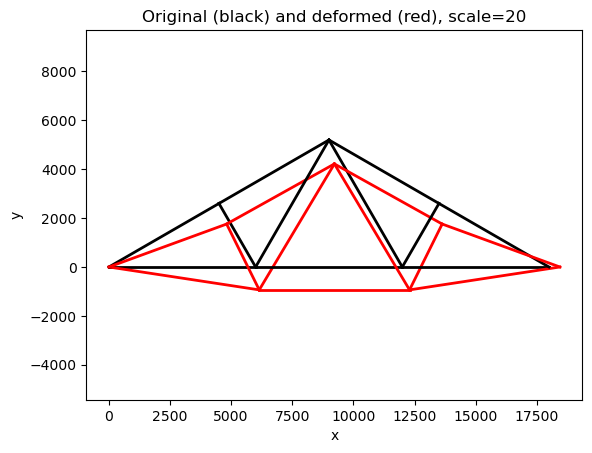

In [248]:
plot_truss_deformation(nodes, elements, u_global, scale=20)

In [249]:
results = recover_element_results(elements, elements_csl, u_global)
df_members = build_element_results_dataframe(elements, elements_csl, results)
display_compact(df_members)

,ele,i,j,L (mm),N (kN),sigma (MPa),u_1 (mm),u_2 (mm),u_3 (mm),u_4 (mm),u_1' (mm),u_2' (mm),u_3' (mm),u_4' (mm),f_1' (kN),f_2' (kN),f_3' (kN),f_4' (kN)
0,1,1,3,6000.0,346.4,86.6,0.0,0.0,7.4,-46.8,0.0,0.0,7.4,-46.8,-346.4,0.0,346.4,0.0
1,2,1,2,5196.2,-400.0,-100.0,0.0,0.0,15.7,-42.1,0.0,0.0,-7.4,-44.3,400.0,0.0,-400.0,0.0
2,3,2,3,3000.0,0.0,0.0,15.7,-42.1,7.4,-46.8,44.3,-7.4,44.3,-17.0,0.0,0.0,0.0,0.0
3,4,2,4,5196.2,-400.0,-100.0,15.7,-42.1,11.1,-49.0,-7.4,-44.3,-14.8,-48.0,400.0,0.0,-400.0,0.0
4,5,3,4,6000.0,0.0,0.0,7.4,-46.8,11.1,-49.0,-36.8,-29.8,-36.8,-34.1,-0.0,0.0,0.0,0.0
5,6,3,5,6000.0,346.4,86.6,7.4,-46.8,14.8,-46.8,7.4,-46.8,14.8,-46.8,-346.4,0.0,346.4,0.0
6,7,4,5,6000.0,-0.0,-0.0,11.1,-49.0,14.8,-46.8,48.0,-14.8,48.0,-10.6,0.0,0.0,-0.0,0.0
7,8,4,6,5196.2,-400.0,-100.0,11.1,-49.0,6.6,-42.1,34.1,-36.8,26.7,-33.1,400.0,0.0,-400.0,0.0
8,9,5,6,3000.0,0.0,0.0,14.8,-46.8,6.6,-42.1,-33.1,-36.3,-33.1,-26.7,0.0,0.0,0.0,0.0
9,10,5,7,6000.0,346.4,86.6,14.8,-46.8,22.3,0.0,14.8,-46.8,22.3,0.0,-346.4,0.0,346.4,0.0


In [250]:
R_df = build_reaction_df(
    nodes_restrained=nodes_restrained,
    node_dofs_1based=node_dofs_1based,
    K_global=K_global,
    u_global=u_global,
    dof_loaded_1based=dof_loaded_1based,
    decimals=3
)

display_compact(R_df)

,node,Rx (kN),Ry (kN)
0,1,0.0,200.0
1,7,-0.0,200.0


In [251]:
df_disp = build_node_displacement_df(nodes, node_dofs_1based, u_global)

df_umax = build_max_displacement_summary(df_disp)

display_compact(df_umax)

,metric,node,value (mm),ux (mm),uy (mm)
0,max |u|,4,50.2,11.1,-49.0
1,max |ux|,7,22.3,22.3,0.0
2,max |uy|,4,-49.0,11.1,-49.0


In [252]:
# Choose one element to sanity-check
e_test = 1

# --- Geometry + properties ---
i, j, E, A = elements[e_test]
c, s, L = elements_csl.get(e_test, element_csL(nodes[i], nodes[j]))

print(f"Element {e_test}: nodes ({i}, {j})")
print(f"c = {c:.6f}, s = {s:.6f}, L = {L:.3f} mm")

# --- Displacements ---
u_e = extract_element_displacements(u_global, i, j)
print(f"u_e (ele {e_test} global displacements) = {u_e}")

u_local = compute_local_displacements(c, s, u_e)
print(f"u_local (ele {e_test} local displacements) = {u_local}")

# --- Forces / stress ---
f_local = compute_local_end_forces(E, A, L, u_local)
print(f"f_local (ele {e_test} local end forces) = {f_local}")

N, sigma = compute_axial_force_and_stress(E, A, L, u_local)
print(f"Axial force  N = {N:.3f} kN")
print(f"Axial stress σ = {sigma:.6f} GPa  ({sigma*1000:.2f} MPa)")

f_global_e = local_to_global_forces(c, s, f_local)
print(f"f_global_e (ele {e_test} end forces in global coords) = {f_global_e}")


Element 1: nodes (1, 3)
c = 1.000000, s = 0.000000, L = 6000.000 mm
u_e (ele 1 global displacements) = [  0.      0.      7.423 -46.835]
u_local (ele 1 local displacements) = [  0.      0.      7.423 -46.835]
f_local (ele 1 local end forces) = [-346.41    0.    346.41    0.  ]
Axial force  N = 346.410 kN
Axial stress σ = 0.086603 GPa  (86.60 MPa)
f_global_e (ele 1 end forces in global coords) = [-346.41    0.    346.41    0.  ]


### YOUR ANSWER FOR Q1.2 IN THIS CELL:

Use as many cells as you need

See previous cells.

---

### Q1.3 Discussion

Compare the support reactions and member foces obtained from your code with those calculated by hand. State whether they agree, and briefly summarize your findings in the final cell using **Markdown** and **LaTeX** as appropriate.

### YOUR ANSWER FOR Q1.3 IN THIS CELL:

Use as many cells as you need

The results are pretty much the same.

---
---

## Question 2 — Case Study Truss Analysis (30 points)

In this question, you will select a real planar truss structure and analyze it using the Direct Stiffness Method.

### Q2.1. Select a Structure
Using the **International Database and Gallery of Structures (Structurae)** or another credible source (<https://structurae.net/en/structures/>), identify a **planar truss structure**. This may be a bridge, roof truss, or building truss.

- Truss bridges are a good starting point:  
  <https://structurae.net/en/structures/bridges/truss-bridges>
- Choose a structure for which you can find a **clear, high-quality image**.
- Include a link to the Structurae (or equivalent) page for your selected structure.

> **Important:** The image of the Quebec bridge below is provided **only as an example** of a suitable structure and level of modeling detail. You should **not** use this bridge.

### Example Truss Structure (Quebec Bridge)
![Example truss bridge](../Lectures/L5/assets/L1_ExampleBridge.png)


### YOUR ANSWER FOR Q2.1 IN THIS CELL:

Use as many cells as you need

https://en.wikipedia.org/wiki/Waibaidu_Bridge

---

### Q2.2. Define Geometry, Properties, and Assumptions
Make reasonable engineering assumptions to idealize the structure as a **2D planar truss**. Clearly document all assumptions.

At minimum, address the following:

- **Geometry**
  - Estimate the overall size (e.g., span length) from published data when available.
  - Scale node locations from an image or drawing (CAD software may be used).
- **Member grouping**
  - Group members into logical categories (e.g., top chord, bottom chord, diagonals, verticals).
  - Assign cross-sectional areas by group; unique areas for every member are *not* required but try to get as granular as possible.
- **Material properties**
  - Assume a Young’s modulus of $E = 200\,\text{GPa}$.
  - Use **metric units** throughout.
- **Boundary conditions**
  - Make reasonable assumptions for supports (e.g., pinned supports are acceptable).


### YOUR ANSWER FOR Q2.2 IN THIS CELL:
Use as many cells as you need

Span: 52.184m, bay length: 4.744m. Features a variable-height truss with a maximum truss height of 9.115m and a minimum truss height of 6.796m. The above data is derived from calculations: By importing images into AutoCAD, component lengths were measured using straight lines, and actual dimensions were determined through proportional calculations.

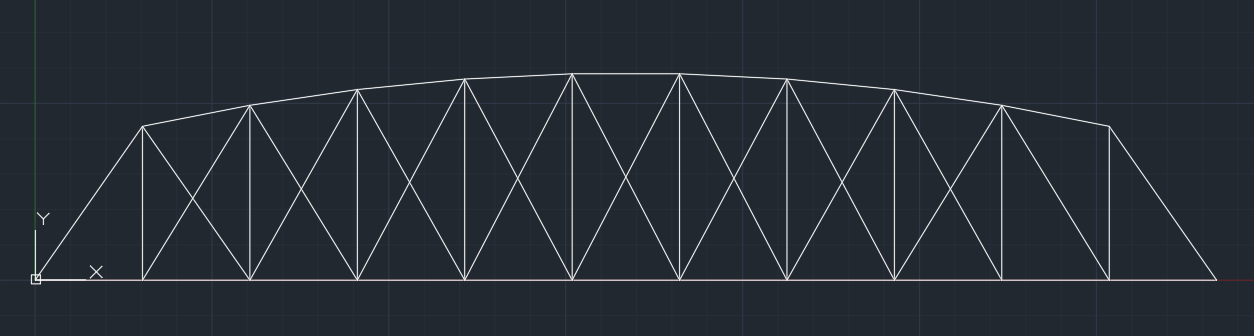

In [253]:
from IPython.display import Image
Image("Screenshot 2026-02-19 145928.png")

---

### Q2.3. Problem Setup
Define all model inputs (nodes, elements, supports, loads) using the same data structures and conventions as in **Question 1**.

Present:
- Node coordinates
- Element connectivity and properties
- Applied loads and boundary conditions


In [254]:
nodes = {
    1:  (0.0,     0.0),      # B0
    2:  (4744.0,  0.0),      # B1
    3:  (4744.0,  6796.0),   # T1

    4:  (9488.0,  0.0),      # B2
    5:  (9488.0,  7724.0),   # T2

    6:  (14232.0, 0.0),      # B3
    7:  (14232.0, 8419.0),   # T3

    8:  (18976.0, 0.0),      # B4
    9:  (18976.0, 8883.0),   # T4

    10: (23720.0, 0.0),      # B5
    11: (23720.0, 9115.0),   # T5

    12: (28464.0, 0.0),      # B6
    13: (28464.0, 9115.0),   # T6

    14: (33208.0, 0.0),      # B7
    15: (33208.0, 8883.0),   # T7

    16: (37952.0, 0.0),      # B8
    17: (37952.0, 8419.0),   # T8

    18: (42696.0, 0.0),      # B9
    19: (42696.0, 7724.0),   # T9

    20: (47440.0, 0.0),      # B10
    21: (47440.0, 6796.0),   # T10

    22: (52184.0, 0.0),      # B11
}

In [255]:
E = 200.0
A = 4000.0

def B(i): return 2*i + 1
def T(i): return 2*i + 2

elements = {
    # Bottom chord (11)
    1:  (1, 2,  E, A),   # B0-B1
    2:  (2, 4,  E, A),   # B1-B2
    3:  (4, 6,  E, A),   # B2-B3
    4:  (6, 8,  E, A),   # B3-B4
    5:  (8, 10, E, A),   # B4-B5
    6:  (10, 12, E, A),  # B5-B6
    7:  (12, 14, E, A),  # B6-B7
    8:  (14, 16, E, A),  # B7-B8
    9:  (16, 18, E, A),  # B8-B9
    10: (18, 20, E, A),  # B9-B10
    11: (20, 22, E, A),  # B10-B11

    # Top chord (9): T1-T2-...-T10
    12: (3, 5,  E, A),   # T1-T2
    13: (5, 7,  E, A),   # T2-T3
    14: (7, 9,  E, A),   # T3-T4
    15: (9, 11, E, A),   # T4-T5
    16: (11, 13, E, A),  # T5-T6
    17: (13, 15, E, A),  # T6-T7
    18: (15, 17, E, A),  # T7-T8
    19: (17, 19, E, A),  # T8-T9
    20: (19, 21, E, A),  # T9-T10

    # Verticals (10): B1-T1 ... B10-T10 (no end verticals)
    21: (2, 3,  E, A),   # B1-T1
    22: (4, 5,  E, A),   # B2-T2
    23: (6, 7,  E, A),   # B3-T3
    24: (8, 9,  E, A),   # B4-T4
    25: (10, 11, E, A),  # B5-T5
    26: (12, 13, E, A),  # B6-T6
    27: (14, 15, E, A),  # B7-T7
    28: (16, 17, E, A),  # B8-T8
    29: (18, 19, E, A),  # B9-T9
    30: (20, 21, E, A),  # B10-T10

    # End posts (2)
    31: (1, 3,  E, A),   # B0-T1
    32: (22, 21, E, A),  # B11-T10

    # X diagonals in interior panels 1..9 (18)
    # Ti -> B{i+1}
    33: (3, 4,  E, A),   # T1-B2
    34: (5, 6,  E, A),   # T2-B3
    35: (7, 8,  E, A),   # T3-B4
    36: (9, 10, E, A),   # T4-B5
    37: (11, 12, E, A),  # T5-B6
    38: (13, 14, E, A),  # T6-B7
    39: (15, 16, E, A),  # T7-B8
    40: (17, 18, E, A),  # T8-B9
    41: (19, 20, E, A),  # T9-B10

    # Bi -> T{i+1}
    42: (2, 5,  E, A),   # B1-T2
    43: (4, 7,  E, A),   # B2-T3
    44: (6, 9,  E, A),   # B3-T4
    45: (8, 11, E, A),   # B4-T5
    46: (10, 13, E, A),  # B5-T6
    47: (12, 15, E, A),  # B6-T7
    48: (14, 17, E, A),  # B7-T8
    49: (16, 19, E, A),  # B8-T9
    50: (18, 21, E, A),  # B9-T10
}

elements_csl = build_elements_csl(elements, nodes)

In [256]:
nodes_restrained = {
    1: ["ux", "uy"],   # pin
    22: ["uy"]          # y-roller
}
nodes_loaded = {
    5: (0.0, -400.0)
}

dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_loaded_1based = loaded_dofs_1based(nodes_loaded, node_dofs_1based)

---


### Q2.4. Analysis
Solve the truss using the planar truss functions developed earlier, following the same workflow as in Q1.

Report key numerical results, such as:
- Support reactions
- Member axial forces
- Maximum nodal displacements
- Present summary tables
- Plot displaced shape at a reasonable scale

In [257]:
print_toggle = 0
K_global = assemble_global_stiffness(elements, nodes, elements_csl, print_toggle)
f_global = assemble_global_force_vector(nodes, dof_loaded_1based)

(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    free_dofs,
    restrained_dofs,
) = partition_system(K_global, f_global, dof_restrained_1based)

u_f = solve_free_displacements(K_ff, K_fr, f_f)
F_r = solve_support_forces(K_rf, K_rr, u_f)
u_global = assemble_global_displacements(u_f, free_dofs, restrained_dofs)
f_global_complete = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs)


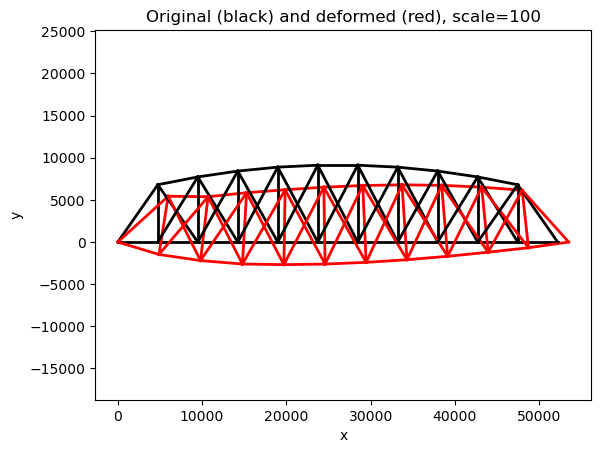

In [258]:
plot_truss_deformation(nodes, elements, u_global, scale=100)

In [259]:
results = recover_element_results(elements, elements_csl, u_global)
df_members = build_element_results_dataframe(elements, elements_csl, results)
display_compact(df_members)

,ele,i,j,L (mm),N (kN),sigma (MPa),u_1 (mm),u_2 (mm),u_3 (mm),u_4 (mm),u_1' (mm),u_2' (mm),u_3' (mm),u_4' (mm),f_1' (kN),f_2' (kN),f_3' (kN),f_4' (kN)
0,1,1,2,4744.0,228.5,57.1,0.0,0.0,1.4,-14.8,0.0,0.0,1.4,-14.8,-228.5,0.0,228.5,0.0
1,2,2,4,4744.0,310.3,77.6,1.4,-14.8,3.2,-22.0,1.4,-14.8,3.2,-22.0,-310.3,0.0,310.3,0.0
2,3,4,6,4744.0,388.3,97.1,3.2,-22.0,5.5,-26.1,3.2,-22.0,5.5,-26.1,-388.3,0.0,388.3,0.0
3,4,6,8,4744.0,295.5,73.9,5.5,-26.1,7.2,-26.8,5.5,-26.1,7.2,-26.8,-295.5,0.0,295.5,0.0
4,5,8,10,4744.0,249.6,62.4,7.2,-26.8,8.7,-26.1,7.2,-26.8,8.7,-26.1,-249.6,0.0,249.6,0.0
5,6,10,12,4744.0,207.3,51.8,8.7,-26.1,10.0,-24.1,8.7,-26.1,10.0,-24.1,-207.3,0.0,207.3,0.0
6,7,12,14,4744.0,171.5,42.9,10.0,-24.1,11.0,-21.0,10.0,-24.1,11.0,-21.0,-171.5,0.0,171.5,0.0
7,8,14,16,4744.0,138.2,34.5,11.0,-21.0,11.8,-16.9,11.0,-21.0,11.8,-16.9,-138.2,0.0,138.2,0.0
8,9,16,18,4744.0,105.7,26.4,11.8,-16.9,12.4,-12.1,11.8,-16.9,12.4,-12.1,-105.7,0.0,105.7,0.0
9,10,18,20,4744.0,65.2,16.3,12.4,-12.1,12.8,-6.8,12.4,-12.1,12.8,-6.8,-65.2,0.0,65.2,0.0


In [260]:
R_df = build_reaction_df(
    nodes_restrained=nodes_restrained,
    node_dofs_1based=node_dofs_1based,
    K_global=K_global,
    u_global=u_global,
    dof_loaded_1based=dof_loaded_1based,
    decimals=3
)

display_compact(R_df)

,node,Rx (kN),Ry (kN)
0,1,0.0,327.3
1,22,-0.0,72.7


In [261]:
df_disp = build_node_displacement_df(nodes, node_dofs_1based, u_global)

df_umax = build_max_displacement_summary(df_disp)

display_compact(df_umax)

,metric,node,value (mm),ux (mm),uy (mm)
0,max |u|,9,28.2,8.7,-26.8
1,max |ux|,22,13.1,13.1,0.0
2,max |uy|,8,-26.8,7.2,-26.8


In [262]:
# Choose one element to sanity-check
e_test = 1

# --- Geometry + properties ---
i, j, E, A = elements[e_test]
c, s, L = elements_csl.get(e_test, element_csL(nodes[i], nodes[j]))

print(f"Element {e_test}: nodes ({i}, {j})")
print(f"c = {c:.6f}, s = {s:.6f}, L = {L:.3f} mm")

# --- Displacements ---
u_e = extract_element_displacements(u_global, i, j)
print(f"u_e (ele {e_test} global displacements) = {u_e}")

u_local = compute_local_displacements(c, s, u_e)
print(f"u_local (ele {e_test} local displacements) = {u_local}")

# --- Forces / stress ---
f_local = compute_local_end_forces(E, A, L, u_local)
print(f"f_local (ele {e_test} local end forces) = {f_local}")

N, sigma = compute_axial_force_and_stress(E, A, L, u_local)
print(f"Axial force  N = {N:.3f} kN")
print(f"Axial stress σ = {sigma:.6f} GPa  ({sigma*1000:.2f} MPa)")

f_global_e = local_to_global_forces(c, s, f_local)
print(f"f_global_e (ele {e_test} end forces in global coords) = {f_global_e}")


Element 1: nodes (1, 2)
c = 1.000000, s = 0.000000, L = 4744.000 mm
u_e (ele 1 global displacements) = [  0.      0.      1.355 -14.753]
u_local (ele 1 local displacements) = [  0.      0.      1.355 -14.753]
f_local (ele 1 local end forces) = [-228.455    0.     228.455    0.   ]
Axial force  N = 228.455 kN
Axial stress σ = 0.057114 GPa  (57.11 MPa)
f_global_e (ele 1 end forces in global coords) = [-228.455    0.     228.455    0.   ]


### YOUR ANSWER FOR Q2.4 IN THIS CELL:

Use as many cells as you need

---


### Q2.5. Discussion
Discuss the computed **member forces** and **nodal displacements**.

Interpret your results from an engineering perspective by addressing the following questions:

- Are the computed displacements and deformed shape physically reasonable for the structure and loading considered?
- Do the signs and magnitudes of member forces and support reactions make sense?
- Which members carry the largest axial forces, and how does this relate to the expected load paths?
- How do your modeling assumptions (geometry, cross-sections, boundary conditions) influence the results?
- Which assumptions do you expect the results to be most sensitive to, and why?


#### Are the computed displacements and deformed shape physically reasonable for the structure and loading considered?

- Yes, they are.

#### Do the signs and magnitudes of member forces and support reactions make sense?

- Yes.

#### Which members carry the largest axial forces, and how does this relate to the expected load paths?

- For Questions 1 and 2, the members with the greatest axial forces are distributed along the outer contour of the truss, consistent with the primary load transmission paths of the truss. For trusses subjected to vertical loads, the overall stress behavior approximates that of an equivalent beam: the upper chord acts as the compressed flange of the beam, while the lower chord functions as the tension flange. Consequently, the outer contour chords must provide the primary tension-compression couples to resist the overall bending moment across the entire span, naturally resulting in maximum axial forces.

#### How do your modeling assumptions (geometry, cross-sections, boundary conditions) influence the results?

- The height of the truss and the length of the bay determine how much equivalent beam bending moment the chord members must bear, thus directly affecting the magnitude of axial force experienced by the members.
- The larger the cross-sectional area of a member, the greater its stiffness, and the more force it can bear.
- Applying additional constraints under statically determinate boundary conditions alters the load transfer path, thereby changing the stress distribution within the members.

#### Which assumptions do you expect the results to be most sensitive to, and why?

- The results are most sensitive to boundary conditions. Changes in boundary conditions typically alter the force transmission paths, thereby modifying the internal force distribution within the structure.
- The results are also highly sensitive to member stiffness. For statically indeterminate structures, altering the cross-sectional area affects the overall stiffness of the structure, which in turn influences the distribution of internal forces.



### YOUR ANSWER FOR Q2.5 IN THIS CELL:

Use as many cells as you need

---

## Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics
- What part felt hardest? Describe in speciics
- One bug you encountered and how you fixed it.
- One thing you still don’t understand.
- If you used collaboration or AI tools, briefly describe how.


### YOUR RESPONSE HERE

#### What part felt easiest? Describe in speciics

- All

#### What part felt hardest? Describe in speciics

- None.

#### One bug you encountered and how you fixed it.

- None.

#### One thing you still don’t understand.

- None.

#### If you used collaboration or AI tools, briefly describe how.

- I used ChatGPT for all the inputs of the elements and nodes.
- The bearing reaction force table was also written with ChatGPT's help.